In [38]:
import os 
import shutil 
import math
import glob
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K  

root_dir = "Covid19-Pneumonia-Normal Chest X-Ray Images Dataset"
number_of_images = {}

for i in os.listdir(root_dir):
    if os.path.isdir(os.path.join(root_dir, i)):
        number_of_images[i] = len(os.listdir(os.path.join(root_dir, i)))

def datafolder(p, split):
    if not os.path.exists("./" + p):
        os.mkdir("./" + p)
        for dir in os.listdir(root_dir):
            if dir != '.DS_Store': 
                os.makedirs("./" + p + "/" + dir)
                
                for img in np.random.choice(a=os.listdir(os.path.join(root_dir, dir)), 
                                             size=(math.floor(split * number_of_images[dir]) - 5), replace=False):
                    src = os.path.join(root_dir, dir, img)
                    dst = os.path.join("./" + p, dir, img)
                    shutil.copy(src, dst)
                    os.remove(src)
    else:
        print(f"{p} Folder exists")

datafolder("train", 0.70)
datafolder("val", 0.15)
datafolder("test", 0.15)

train Folder exists
val Folder exists
test Folder exists


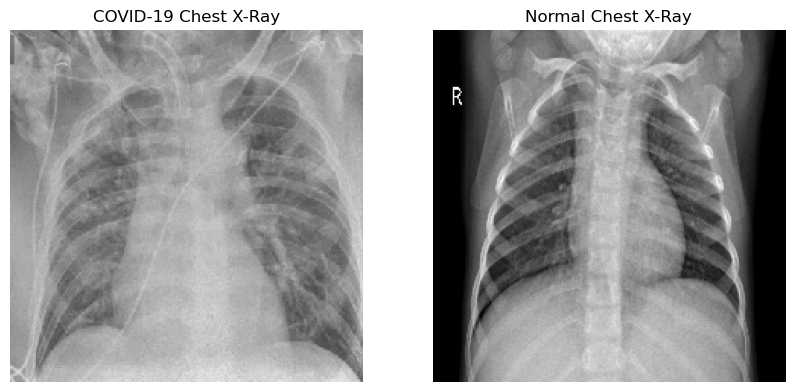

In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

covid_dir = "train/COVID"
normal_dir = "train/NORMAL"

covid_img_path = os.path.join(covid_dir, os.listdir(covid_dir)[0])
normal_img_path = os.path.join(normal_dir, os.listdir(normal_dir)[0])

plt.figure(figsize=(10, 5))

# covid19 image
plt.subplot(1, 2, 1)
img_covid = mpimg.imread(covid_img_path)
plt.imshow(img_covid, cmap='gray')
plt.title("COVID-19 Chest X-Ray")
plt.axis('off')

# normak image
plt.subplot(1, 2, 2)
img_normal = mpimg.imread(normal_img_path)
plt.imshow(img_normal, cmap='gray')
plt.title("Normal Chest X-Ray")
plt.axis('off')

plt.show()

In [40]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
train_data=train_datagen.flow_from_directory(
    directory="train", 
    target_size=(224,224), 
    batch_size=32, 
    class_mode='binary',
    shuffle=False
)


test_datagen = ImageDataGenerator(
    rescale=1./255
)
test_data = test_datagen.flow_from_directory(
    directory="test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

val_datagen =ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_data = val_datagen.flow_from_directory(
    directory="val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 2389 images belonging to 2 classes.
Found 503 images belonging to 2 classes.
Found 503 images belonging to 2 classes.


In [41]:
actual_labels = np.concatenate([next(test_data)[1] for _ in range(len(test_data))], axis=0)

In [42]:
train_data.class_indices

{'COVID': 0, 'NORMAL': 1}

In [43]:
model = Sequential()
model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(rate=0.25))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(rate=0.25))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(rate=0.25))

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(rate=0.25))


model.add(Flatten())
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(rate=0.25))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,277,217 (4.87 MB)

 Trainable params: 1,277,217 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
es = EarlyStopping(monitor='val_loss', patience=3, verbose=1, min_delta=0, mode='auto')
mc = ModelCheckpoint(filepath='bestmodel.keras', monitor='val_accuracy', mode='auto', save_best_only=True, verbose=1)
history = model.fit(train_data,
                    epochs=20,
                    validation_data=val_data,
                    validation_steps=16,
                    callbacks=[es, mc])

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.4271 - loss: 1.4539
Epoch 1: val_accuracy improved from None to 0.52684, saving model to bestmodel.keras

Epoch 1: finished saving model to bestmodel.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 26s 325ms/step - accuracy: 0.4244 - loss: 0.8958 - val_accuracy: 0.5268 - val_loss: 0.6931
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.5535 - loss: 0.6992
Epoch 2: val_accuracy did not improve from 0.52684
75/75 ━━━━━━━━━━━━━━━━━━━━ 24s 319ms/step - accuracy: 0.5274 - loss: 0.6980 - val_accuracy: 0.5268 - val_loss: 0.6914
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.5891 - loss: 0.6918
Epoch 3: val_accuracy improved from 0.52684 to 0.85885, saving model to bestmodel.keras

Epoch 3: finished saving model to bestmodel.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 24s 319ms/step - accuracy: 0.6162 - loss: 0.7033 - val_accuracy: 0.8588 - val_loss: 0.6207
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy

In [45]:
from tensorflow.keras.models import load_model

model = load_model("bestmodel.keras")

test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9622 - loss: 0.1739
Test Loss: 0.17391131818294525
Test Accuracy: 0.9622266292572021


In [46]:
from keras.models import load_model

# eğitilmiş modeli yükle
model = load_model("bestmodel.keras")

# Make predictions
prediction1 = model.predict(test_data)
predicted_classes = prediction1 > 0.5

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


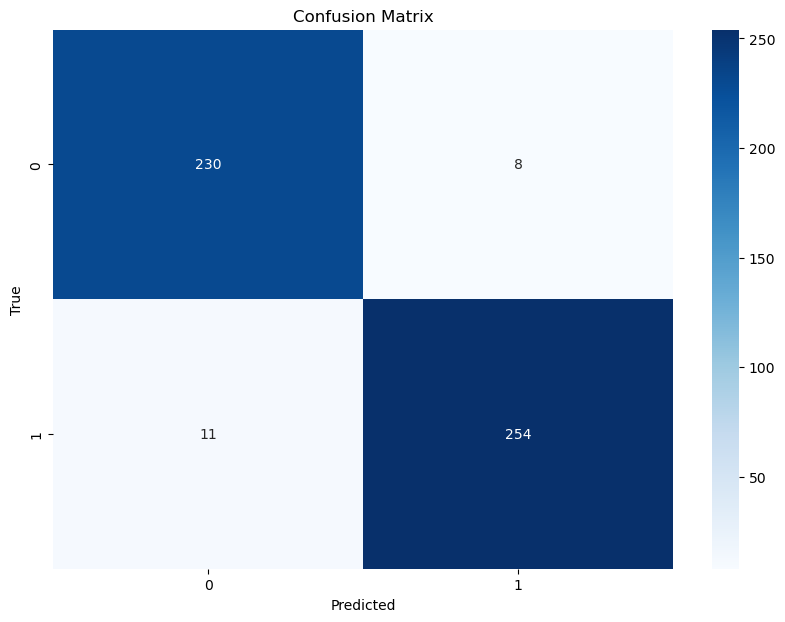

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(actual_labels, predicted_classes)


plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [48]:
h=history.history
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

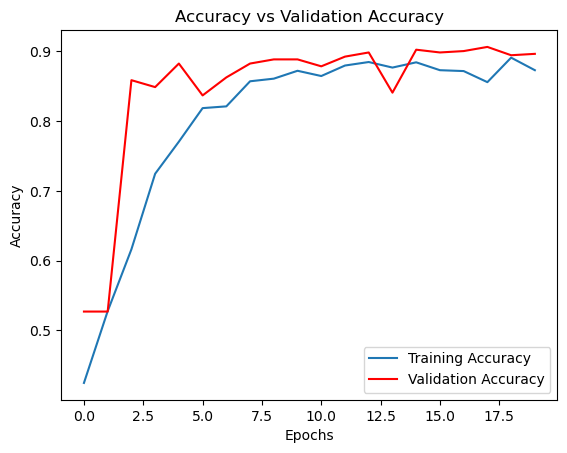

In [49]:
import matplotlib.pyplot as plt

plt.plot(h['accuracy'], label='Training Accuracy')
plt.plot(h['val_accuracy'], c='red', label='Validation Accuracy')

plt.title("Accuracy vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend() 

plt.show()

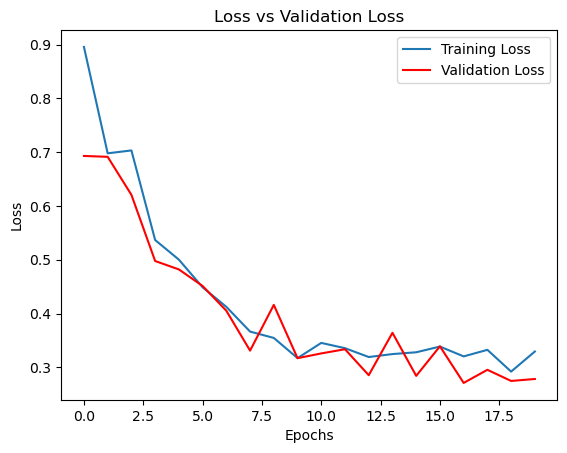

In [50]:


import matplotlib.pyplot as plt

plt.plot(h['loss'], label='Training Loss')
plt.plot(h['val_loss'], c='red', label='Validation Loss')

plt.title("Loss vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend() 

plt.show()

In [51]:
import os
import cv2
import numpy as np

def detect_ROI(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blurred, 50, 150)

    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:

        contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(contour)
        return x, y, w, h
    return None

input_folder = "image_test"
output_folder = "Detected_ROI_Images/"


os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.endswith(".png") or filename.endswith(".jpg"):
        image_path = os.path.join(input_folder, filename)
        image = cv2.imread(image_path)
        predictions = model.predict(np.expand_dims(cv2.resize(image, (224, 224)) / 255.0, axis=0))
        covid_probability = predictions[0][0]
        threshold = 0.5
        pred_class = 1 if predictions[0][0] > threshold else 0

        if pred_class == 0:
            roi = detect_ROI(image)
            if roi:
                x, y, w, h = roi
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
                text = f"COVID: {covid_probability:.2f}"
                cv2.putText(image, text, (x -20, y -10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
                output_path = os.path.join(output_folder, filename)
                cv2.imwrite(output_path, image)
            else:
                print(f"No ROI detected in {filename}")
        else:
            print(f"The patient in {filename} is negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
The patient in COVID_28.png is negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
The patient in COVID_419.png is negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━

In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    "./train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    "./val",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    "./test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

print(train_data.class_indices)

Found 2389 images belonging to 2 classes.
Found 503 images belonging to 2 classes.
Found 503 images belonging to 2 classes.
{'COVID': 0, 'NORMAL': 1}


In [57]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow.keras.backend as K

K.clear_session()

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.7)(x)
predictions = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions)

es = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

mc = ModelCheckpoint(
    filepath="densenet_sigmoid_best.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[es, mc]
)

test_loss, test_acc = model.evaluate(test_data)

print(f"Final Model Performance - Test Accuracy: {test_acc:.4f}")
print(f"Final Model Performance - Test Loss: {test_loss:.4f}")

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 996ms/step - accuracy: 0.5275 - loss: 1.0715
Epoch 1: val_loss improved from None to 0.55696, saving model to densenet_sigmoid_best.keras

Epoch 1: finished saving model to densenet_sigmoid_best.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.5266 - loss: 1.0363 - val_accuracy: 0.7575 - val_loss: 0.5570
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.5734 - loss: 0.9053
Epoch 2: val_loss improved from 0.55696 to 0.44273, saving model to densenet_sigmoid_best.keras

Epoch 2: finished saving model to densenet_sigmoid_best.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5931 - loss: 0.8676 - val_accuracy: 0.8748 - val_loss: 0.4427
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6427 - loss: 0.7837
Epoch 3: val_loss improved from 0.44273 to 0.36325, saving model to densenet_sigmoid_best.keras

Epoch 3: finished saving model to densenet_sigmoid_best.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - 

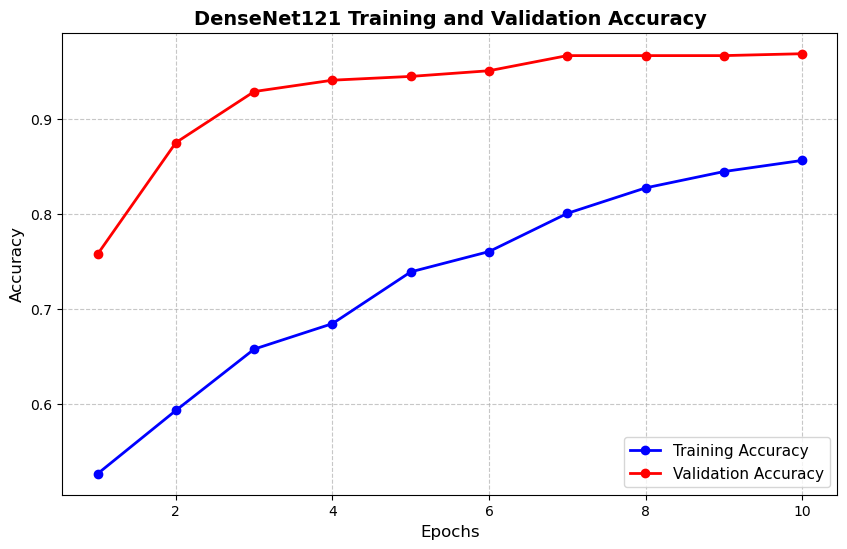

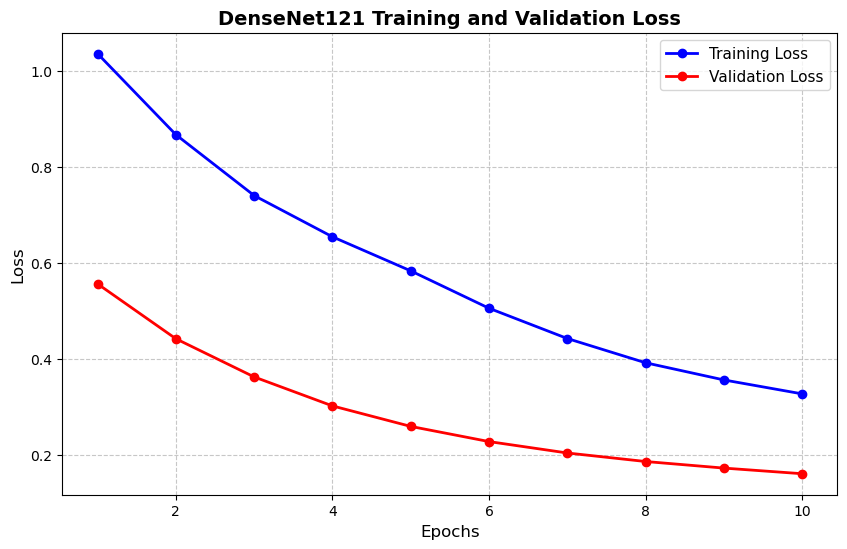

In [58]:
import matplotlib.pyplot as plt


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Gerçekleşen epoch sayısına göre X eksenini oluşturuyoruz
epochs_range = range(1, len(acc) + 1)

# ==========================================
# --- Plot 1: Accuracy (Doğruluk Grafiği) ---
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, acc, 'bo-', linewidth=2, label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'ro-', linewidth=2, label='Validation Accuracy')
plt.title('DenseNet121 Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# --- Plot 2: Loss (Kayıp Grafiği) ---
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, loss, 'bo-', linewidth=2, label='Training Loss')
plt.plot(epochs_range, val_loss, 'ro-', linewidth=2, label='Validation Loss')
plt.title('DenseNet121 Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [59]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = (224, 224)
TEST_DIR = "./test"

# Select one COVID and one NORMAL image from the test set
covid_images = glob.glob(os.path.join(TEST_DIR, "COVID", "*"))
normal_images = glob.glob(os.path.join(TEST_DIR, "NORMAL", "*"))

image_paths = [covid_images[0], normal_images[0]]
image_titles = ["COVID X-ray", "NORMAL X-ray"]

class_names = list(test_data.class_indices.keys())

print("Class indices:", test_data.class_indices)
print("COVID image:", image_paths[0])
print("NORMAL image:", image_paths[1])


def load_image_for_model(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)

    img_display = img_array.astype("uint8")
    img_preprocessed = preprocess_input(np.expand_dims(img_array, axis=0))

    return img_display, img_preprocessed


def compute_gradcam_sigmoid(model, img_preprocessed, pred_class, layer_name="conv5_block16_concat"):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, prediction = grad_model(img_preprocessed)

        # Sigmoid output gives probability of class 1
        # If predicted class is 1, explain prediction directly.
        # If predicted class is 0, explain 1 - prediction.
        if pred_class == 1:
            class_score = prediction[:, 0]
        else:
            class_score = 1 - prediction[:, 0]

    gradients = tape.gradient(class_score, conv_output)
    weights = tf.reduce_mean(gradients, axis=(0, 1, 2))

    heatmap = tf.reduce_sum(weights * conv_output[0], axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE)

    return tf.squeeze(heatmap).numpy()

Class indices: {'COVID': 0, 'NORMAL': 1}
COVID image: ./test/COVID/COVID_1322.png
NORMAL image: ./test/NORMAL/NORMAL_855.png


16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step
Class indices: {'COVID': 0, 'NORMAL': 1}


<Figure size 600x500 with 0 Axes>

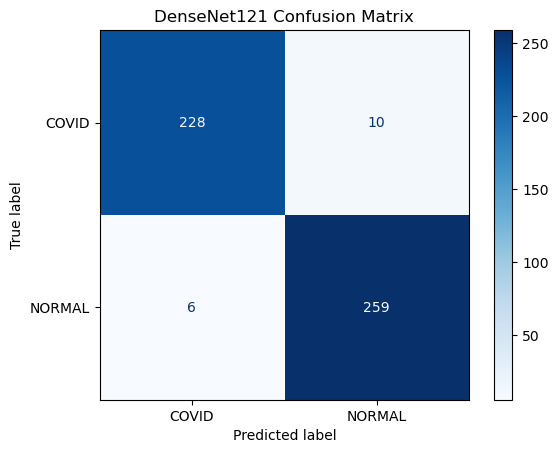

              precision    recall  f1-score   support

       COVID       0.97      0.96      0.97       238
      NORMAL       0.96      0.98      0.97       265

    accuracy                           0.97       503
   macro avg       0.97      0.97      0.97       503
weighted avg       0.97      0.97      0.97       503



In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Make sure test_data order is fixed
test_data.reset()

# Predict probabilities
y_pred_prob = model.predict(test_data)

# Sigmoid model:
# output >= 0.5 = class 1
# output < 0.5 = class 0
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

# True labels
y_true = test_data.classes

# Class names from generator
class_names = list(test_data.class_indices.keys())

print("Class indices:", test_data.class_indices)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("DenseNet121 Confusion Matrix")
plt.show()

# Optional: detailed metrics
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


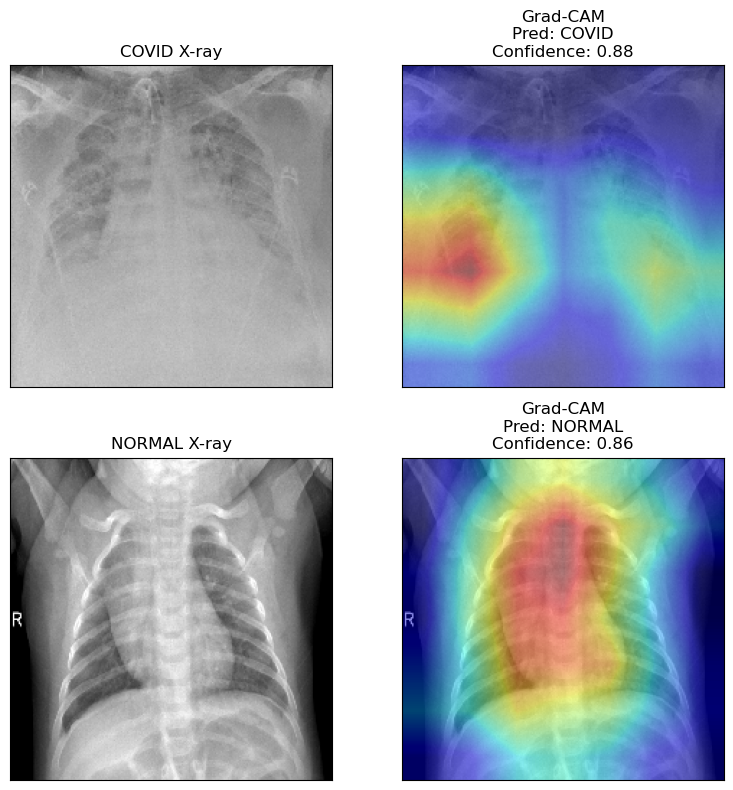

In [60]:
fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 8),
    subplot_kw={"xticks": [], "yticks": []}
)

for i, img_path in enumerate(image_paths):
    img_display, img_preprocessed = load_image_for_model(img_path)

    # Sigmoid prediction: one probability value
    pred_prob_raw = model.predict(img_preprocessed)[0][0]

    # Class 1 if probability >= 0.5, otherwise class 0
    pred_class = 1 if pred_prob_raw >= 0.5 else 0

    # Confidence of the predicted class
    confidence = pred_prob_raw if pred_class == 1 else 1 - pred_prob_raw

    pred_label = class_names[pred_class]

    heatmap = compute_gradcam_sigmoid(
        model=model,
        img_preprocessed=img_preprocessed,
        pred_class=pred_class
    )

    # Original image
    ax[i][0].imshow(img_display)
    ax[i][0].set_title(image_titles[i], fontsize=12)

    # Grad-CAM overlay
    ax[i][1].imshow(img_display)
    ax[i][1].imshow(heatmap, cmap="jet", alpha=0.45)
    ax[i][1].set_title(
        f"Grad-CAM\nPred: {pred_label}\nConfidence: {confidence:.2f}",
        fontsize=12
    )

plt.tight_layout()
plt.show()